# Modal Analysis on an MDOF System

## Introduction

This notebook demonstrates a structured workflow for running a modal analysis on a calibrated multi-degree-of-freedom (MDOF) stick model derived from an SDOF spectral capacity curve.

Two steps are covered:

1. **Calibrate and compile an MDOF model** — Derive per-storey force-deformation backbones from an SDOF capacity curve (Sd–Sa) using the `calibrate_model` function, then assemble the OpenSees stick model with the `modeller` class.

2. **Run modal analysis** — Compute natural periods, mode shapes, and modal participation factors for the calibrated MDOF system using OpenSees eigenvalue analysis.

---

## References

[1] Priestley, M., Calvi, G. and Kowalski, M. (2007) *Displacement-Based Seismic Design of Structures*. IUSS Press, Pavia.

[2] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. *Earthquake Spectra*. 2020;36(2):806–831. doi:10.1177/8755293019891724

## Initialise Libraries

In [ ]:
import numpy as np

from openquake.vmtk.calibration import calibrate_model
from openquake.vmtk.modeller import modeller
from openquake.vmtk.plotter import plotter
from openquake.vmtk.units import units

## Calibrate an MDOF Model from an SDOF Capacity Curve

### Input Parameters

The following parameters are required by `calibrate_model` to derive the per-storey properties of the MDOF model. The storey masses, drift backbones, and force backbones are **not** specified manually — they are derived automatically and passed to `modeller`.

| Parameter | Type | Description |
|---|---|---|
| `number_storeys` | `int` | Number of storeys in the target MDOF building. |
| `sdof_capacity` | `ndarray (n_points × 2)` | SDOF spectral capacity curve: column 0 is Sd [m], column 1 is Sa [g]. The first row defines the yield point, used to compute T* = 2π√(Sd₀ / (Sa₀·g)). |
| `isSOS` | `bool` | `True` reduces ground-floor stiffness by a factor of 0.35 to represent a soft-storey (pilotis) mechanism. |
| `storey_heights` | `list[float]` | Storey heights [m], one entry per storey. Used to scale the mode shape and build the internal stiffness matrix. |
| `verbose` | `bool` | `True` prints calibration diagnostics to stdout; `False` suppresses all output. |

In [ ]:
# Number of storeys
number_storeys = 9

# Relative floor heights list
storey_heights = [2.80] * number_storeys

# SDOF capacity with a trilinear backbone
sdof_capacity = np.array(
    [
        [0.009891, 0.079128, 0.2142],    # spectral displacements [m]
        [0.2356000, 0.4712500, 0.47596],  # spectral accelerations [g]
    ]
).T

# Soft-storey mechanism flag
isSOS = False

# Degradation flag
mdof_degradation = False

# Inherent damping
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(
    number_storeys,
    sdof_capacity,
    is_sos=isSOS,
    storey_heights=storey_heights,
    verbose=False,
)

## Compile the MDOF Model

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2003 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2004 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2005 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2006 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2007 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2008 has L= 2.8, which is greater than the tolerance


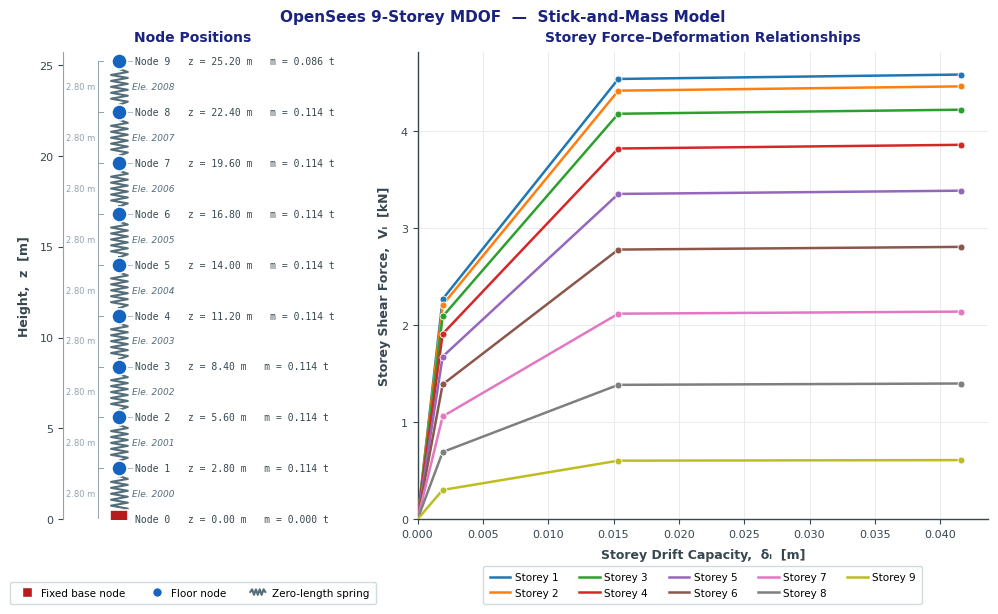

In [ ]:
# Initialise the modeller class and compile the MDOF model
model = modeller(
    number_storeys,
    storey_heights,
    floor_masses,
    storey_drifts,
    storey_forces * units.g,
    mdof_degradation,
)
model.compile_model()

# Visualise the stick model
model.plot_model(pFlag=True, export_path="./out/mdof_model.png")

# Do gravity analysis for system equilibrium
model.do_gravity_analysis()

## Run Modal Analysis

### Input Parameters

After compiling the model, `do_modal_analysis` solves the generalised eigenvalue problem K·φ = ω²·M·φ to extract natural periods and mode shapes. The following parameters control the analysis:

| Parameter | Type | Default | Description |
|---|---|---|---|
| `num_modes` | `int` | `3` | Number of modes to extract. Should not exceed the number of storeys. |
| `solver` | `str` | `'-genBandArpack'` | Eigenvalue solver used by OpenSees. `'-genBandArpack'` uses a generalised banded Arnoldi method suitable for large sparse systems. |
| `doRayleigh` | `bool` | `False` | `True` applies Rayleigh damping based on the extracted frequencies; `False` skips damping assignment. |
| `pFlag` | `bool` | `False` | `True` prints the fundamental period and modal properties report to the console. |
| `plot_modes` | `bool` | `True` | `True` plots all extracted mode shapes against the undeformed stick geometry. |
| `export_path` | `str` | `None` | File path to save the mode shape plot (e.g., `'out/modal_analysis.png'`). If `None`, the plot is displayed but not saved. |

The output of `do_modal_analysis` includes the natural periods of vibration an mode shapes. If `pFlag` is set to `True`, an additional modal analysis summary is reported.

Using DomainModalProperties - Developed by: Massimo Petracca, Guido Camata, ASDEA Software Technology
# MODAL ANALYSIS REPORT

* 1. DOMAIN SIZE:
# This is the size of the problem: 1 for 1D problems, 2 for 2D problems, 3 for 3D problems.
3


* 2. EIGENVALUE ANALYSIS:
#          MODE        LAMBDA         OMEGA     FREQUENCY        PERIOD
# ------------- ------------- ------------- ------------- -------------
              1       233.671       15.2863       2.43289      0.411034
              2       233.671       15.2863       2.43289      0.411034
              3       1283.25       35.8225       5.70133      0.175398
              4       1283.25       35.8225       5.70133      0.175398
              5       3024.69       54.9972       8.75307      0.114246
              6       3024.69       54.9972       8.75307      0.114246
              7       5581.83       74.7117       11.8907     0.0840991
              8       5581.83       74.7117       11.8907     0.0840991
             

Fundamental Period: T = 0.411 s


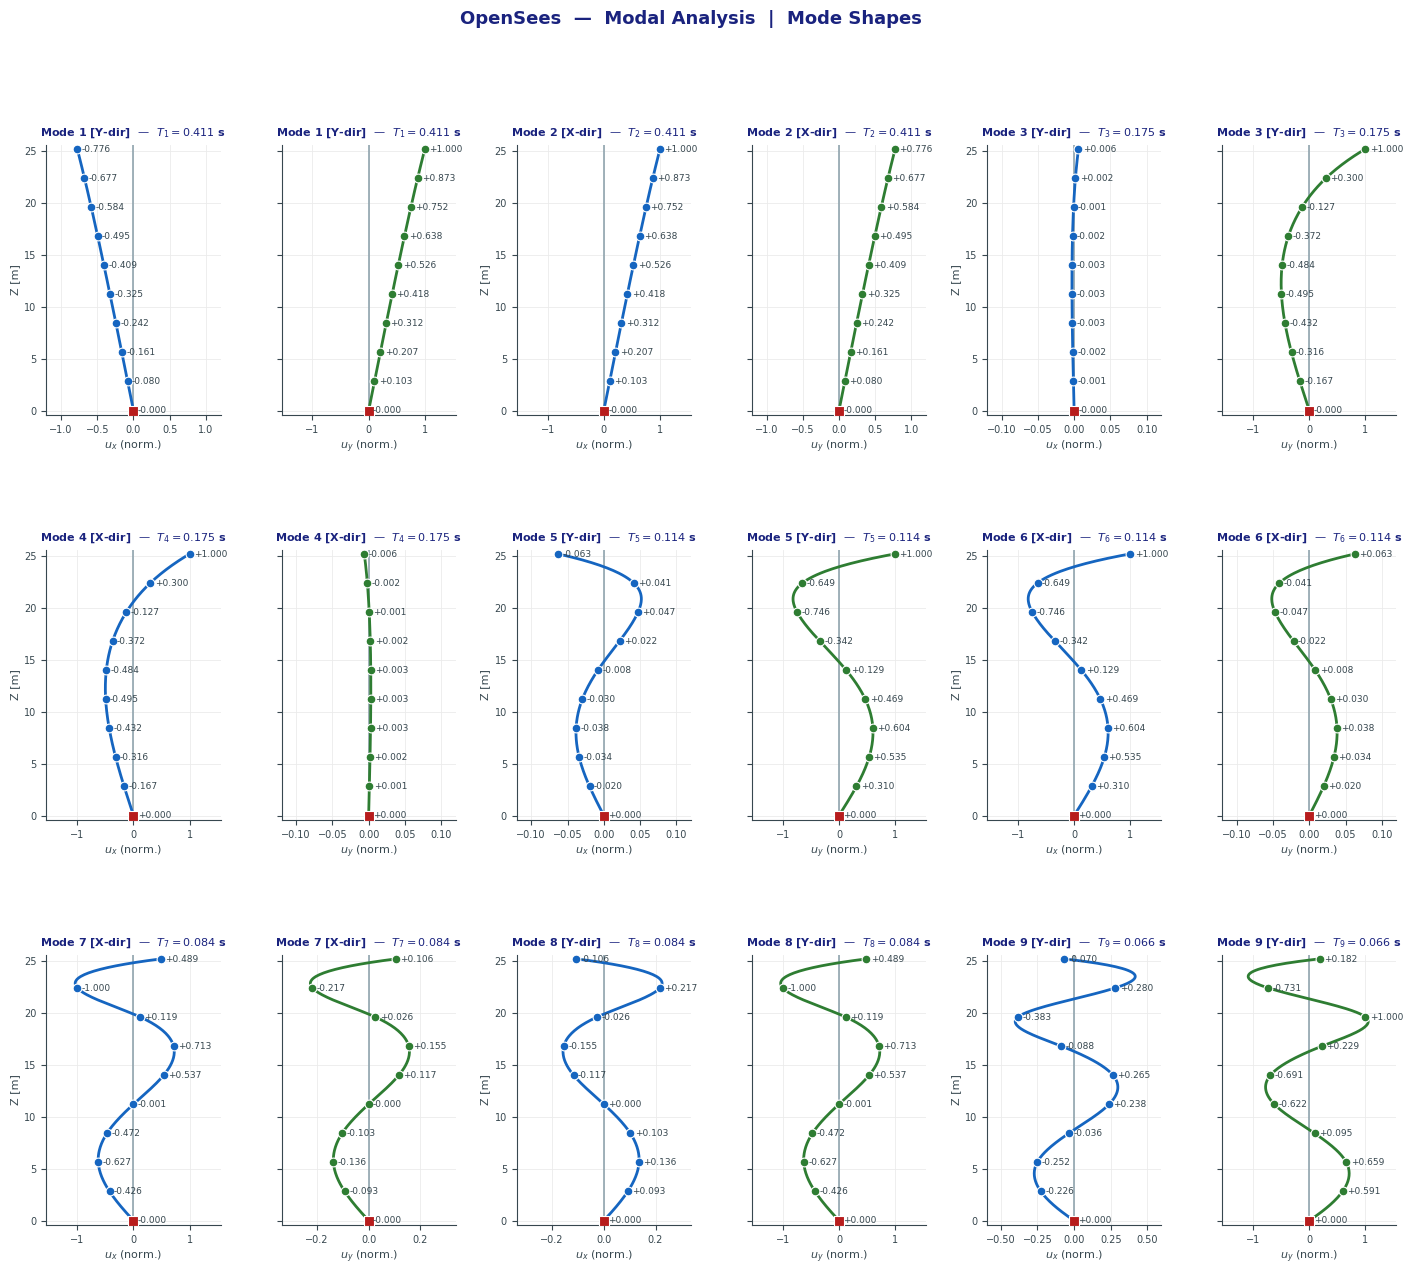

In [ ]:
# Do modal analysis
num_modes = 9
T, phi = model.do_modal_analysis(
    num_modes=num_modes,  # Get N-modes
    pFlag=True,  # Prints modal analysis report
    plot_modes=True,  # Plots modal analysis results
    export_path="out/modal_analysis.png",
)  # Exports modal analysis results